# Day 2 — Preprocessing and Logistic Regression baseline

This notebook first builds the **preprocessing pipeline** for NSL-KDD, then trains a **Logistic Regression** baseline.

We still **do not** train Random Forest or XGBoost, and we **do not** use SMOTE or hyperparameter tuning.

## 1. Why this preprocessing design

### 1. What data leakage is

**Data leakage** is when the model (or its preprocessing) sees information it would not have in a real deployment. Examples: using `label` as a feature, mixing train and test, or computing scaler means from the test set. Leakage makes scores look better than they will be on new traffic.

### 2. Why preprocessing must be fitted only on training data

`StandardScaler` learns a mean and standard deviation. `OneHotEncoder` learns which category values exist. Those statistics must come from **KDDTrain+ only**. If we fit on test (or train+test), test information leaks into the transformation, and evaluation is no longer honest.

### 3. Why we use ColumnTransformer

The 41 features are mixed: 3 text columns and 38 numeric columns. They need **different** treatments. `ColumnTransformer` applies OneHotEncoder to the categorical list and StandardScaler to the numerical list, then concatenates the results. We do not scale strings or one-hot encode byte counts.

### 4. Why categorical features need OneHotEncoder

`protocol_type`, `service`, and `flag` are strings (`tcp`, `http`, `SF`, …). Logistic Regression (later) needs numbers. One-hot encoding creates 0/1 columns for each category so the model does not treat category names as ordered magnitudes.

### 5. Why OneHotEncoder must use `handle_unknown="ignore"`

KDDTest+ contains **service (and possibly other) values that never appear in training**. The default encoder would **error** on unknown categories. `handle_unknown="ignore"` encodes unknown values as all zeros in those one-hot columns, so transform still succeeds and the number of output columns stays the same as training.

### 6. Why numerical features are scaled for Logistic Regression

Logistic Regression uses a weighted sum of features. `src_bytes` can be huge while rate features stay in `[0, 1]`. Unscaled large columns can dominate. `StandardScaler` puts numeric columns on a comparable scale (mean 0, variance 1). We fit those means/stds on **train only**. (Tree models later generally do not need this; we still include it in this shared preprocessor for the linear baseline.)

### 7. Why preprocessing should be inside an sklearn Pipeline

A `Pipeline` bundles steps so we cannot accidentally fit the scaler on test, forget to encode, or apply steps in the wrong order. Later we will add a classifier **after** this same preprocess step. For today the pipeline contains **only** preprocessing.

### 8. Why the test set must remain untouched until evaluation

KDDTest+ is the held-out estimate of real-world performance. We may **transform** it with a pipeline already fitted on train, but we must not **fit** anything on it, not merge it with train, and not tune using its labels until we are ready to report metrics (a later step).

## 2. Imports

Only libraries needed to load tables and build the preprocessor. No classifiers.

In [6]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

## 3. Load NSL-KDD and recreate Day 1 X / y

Same 43 column names, same five-class map, same 41 predictive features as `01_eda.ipynb`.
Train and test stay in **separate** DataFrames.

In [7]:
COLUMNS = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "label",
    "difficulty",
]

attack_category_map = {
    "normal": "Normal",
    "back": "DoS",
    "land": "DoS",
    "neptune": "DoS",
    "pod": "DoS",
    "smurf": "DoS",
    "teardrop": "DoS",
    "apache2": "DoS",
    "udpstorm": "DoS",
    "processtable": "DoS",
    "mailbomb": "DoS",
    "worm": "DoS",
    "satan": "Probe",
    "ipsweep": "Probe",
    "nmap": "Probe",
    "portsweep": "Probe",
    "mscan": "Probe",
    "saint": "Probe",
    "guess_passwd": "R2L",
    "ftp_write": "R2L",
    "imap": "R2L",
    "phf": "R2L",
    "multihop": "R2L",
    "warezmaster": "R2L",
    "warezclient": "R2L",
    "spy": "R2L",
    "xlock": "R2L",
    "xsnoop": "R2L",
    "snmpguess": "R2L",
    "snmpgetattack": "R2L",
    "httptunnel": "R2L",
    "sendmail": "R2L",
    "named": "R2L",
    "buffer_overflow": "U2R",
    "loadmodule": "U2R",
    "rootkit": "U2R",
    "perl": "U2R",
    "sqlattack": "U2R",
    "xterm": "U2R",
    "ps": "U2R",
}

train_path = "../data/raw/KDDTrain+.txt"
test_path = "../data/raw/KDDTest+.txt"

train_df = pd.read_csv(train_path, header=None, names=COLUMNS)
test_df = pd.read_csv(test_path, header=None, names=COLUMNS)

train_df["attack_category"] = train_df["label"].map(attack_category_map)
test_df["attack_category"] = test_df["label"].map(attack_category_map)

feature_columns = [col for col in COLUMNS if col not in ["label", "difficulty"]]

X_train = train_df[feature_columns]
X_test = test_df[feature_columns]
y_train = train_df["attack_category"]
y_test = test_df["attack_category"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("Number of predictive features:", len(feature_columns))

X_train shape: (125973, 41)
X_test shape: (22544, 41)
y_train shape: (125973,)
y_test shape: (22544,)
Number of predictive features: 41


## 4. Categorical vs numerical feature lists

These lists tell `ColumnTransformer` which transformer to apply to which columns.

In [8]:
categorical_features = ["protocol_type", "service", "flag"]
numerical_features = [col for col in feature_columns if col not in categorical_features]

print("Categorical features (", len(categorical_features), "):", sep="")
print(categorical_features)
print()
print("Numerical features (", len(numerical_features), "):", sep="")
print(numerical_features)

Categorical features (3):
['protocol_type', 'service', 'flag']

Numerical features (38):
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


## 5. Build the preprocessor (not fitted yet)

- `OneHotEncoder(handle_unknown="ignore")` for the 3 text columns
- `StandardScaler()` for the 38 numeric columns
- `ColumnTransformer` routes each group to the right transformer
- `preprocessing_pipeline` wraps that as a single sklearn object

No classifier is added.

In [9]:
categorical_transformer = OneHotEncoder(handle_unknown="ignore")
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", numerical_transformer, numerical_features),
    ]
)

preprocessing_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
    ]
)

preprocessing_pipeline

,steps,"[('preprocess', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 6. Fit on train only, then transform train and test

`fit` learns category lists and numeric mean/std from **X_train only**.
`transform` then applies those same learned rules to train and to test.
We never call `fit` on `X_test`.

In [10]:
preprocessing_pipeline.fit(X_train)

X_train_transformed = preprocessing_pipeline.transform(X_train)
X_test_transformed = preprocessing_pipeline.transform(X_test)

print("Original X_train shape:", X_train.shape)
print("Transformed X_train shape:", X_train_transformed.shape)
print("Transformed X_test shape:", X_test_transformed.shape)
print()

same_n_columns = X_train_transformed.shape[1] == X_test_transformed.shape[1]
print("Train and test have the same number of transformed columns:", same_n_columns)

if not same_n_columns:
    raise ValueError("Transformed train and test column counts differ.")

Original X_train shape: (125973, 41)
Transformed X_train shape: (125973, 122)
Transformed X_test shape: (22544, 122)

Train and test have the same number of transformed columns: True


## 7. Why we transform X_test with the already-fitted pipeline

After `fit(X_train)`, the pipeline stores:

- which one-hot columns exist (from training categories only)
- the mean and standard deviation of each numeric column (from training only)

`transform(X_test)` **reuses** those stored values. That is what a real detector would do: apply the rules learned from past traffic to new traffic.

If we fitted a **new** encoder/scaler on `X_test`:

- test means would leak into the transformation
- one-hot columns could differ (test-only `service` values), so train and test would not share the same feature space
- later model scores would be optimistic and not comparable

Unknown test categories are handled by `handle_unknown="ignore"` (all-zero one-hot), so the **column count stays aligned** with training.

The transformed matrices are **wider** than 41 columns because each categorical value becomes its own 0/1 column, then the 38 scaled numeric columns are appended.

The next section adds Logistic Regression **after** this same preprocessor, inside a new pipeline. The test set is still not used for fitting.

## 8. Why Logistic Regression as the first baseline

### 1. Why this model is useful here

Logistic Regression is a **simple, linear** classifier. It is fast to reason about, uses the same sklearn `Pipeline` we already designed, and gives a **floor** for later models (Random Forest, XGBoost). If a more complex model cannot beat this baseline, something is wrong with the setup—not just “we need a bigger model.”

### 2. What multi-class classification means for us

Each connection belongs to **exactly one** of five labels: **Normal, DoS, Probe, R2L, U2R**. The model outputs one of those five for every test row. That is multi-class classification (not binary “attack vs normal”).

### 3. Why Logistic Regression benefits from StandardScaler

It scores a class with a **weighted sum** of features. Unscaled columns on huge scales (bytes) can drown columns on `[0, 1]` (rates). Our preprocessor already applies `StandardScaler` to the 38 numeric features, so this baseline is using that design.

### 4. Why we train only on `X_train` and `y_train`

`fit` must see only KDDTrain+. Fitting on test, or on train+test, is leakage: the model would memorize evaluation traffic and the test score would not be a fair estimate of new data.

### 5. Why we evaluate on `X_test` only after training

KDDTest+ stays **held out** until `predict`. We then compare predictions to `y_test`. That mimics deploying a detector on new traffic it was not trained on (including some attack names never seen in training).

### 6. Why accuracy is not enough

Accuracy is the fraction of rows that are correct. Test data is still dominated by Normal and DoS. A model can look “good” while missing **R2L** and **U2R**. We also report **macro** precision, recall, and F1 (unweighted average over the five classes) and a **per-class** report plus a **confusion matrix**.

## 9. Logistic Regression pipeline

We reuse the existing `preprocessor` (`ColumnTransformer`: one-hot + scaling). `logistic_pipeline` adds `LogisticRegression` as the next step.

- `max_iter=1000` — more optimizer steps so it is likelier to converge on this dataset  
- `class_weight="balanced"` — up-weight rare classes (R2L, U2R) during training; this is **not** SMOTE  
- `random_state=42` — reproducible solver behavior where it applies  

`fit` uses **only** `X_train` and `y_train`. Fitting may take a couple of minutes.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns

category_order = ["Normal", "DoS", "Probe", "R2L", "U2R"]

logistic_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

logistic_pipeline.fit(X_train, y_train)
y_pred = logistic_pipeline.predict(X_test)

print("logistic_pipeline fitted on X_train / y_train.")
print("Predictions generated on X_test only.")

logistic_pipeline fitted on X_train / y_train.
Predictions generated on X_test only.


## 10. Test-set metrics

All scores below compare `y_pred` to `y_test`. Macro metrics treat the five classes equally, so a failure on U2R hurts as much as a failure on Normal.

In [12]:
accuracy = accuracy_score(y_test, y_pred)
macro_precision = precision_score(
    y_test, y_pred, average="macro", labels=category_order, zero_division=0
)
macro_recall = recall_score(
    y_test, y_pred, average="macro", labels=category_order, zero_division=0
)
macro_f1 = f1_score(
    y_test, y_pred, average="macro", labels=category_order, zero_division=0
)

print(f"Accuracy:        {accuracy:.4f}")
print(f"Macro precision: {macro_precision:.4f}")
print(f"Macro recall:    {macro_recall:.4f}")
print(f"Macro F1:        {macro_f1:.4f}")

Accuracy:        0.7893
Macro precision: 0.6871
Macro recall:    0.6727
Macro F1:        0.6024


## 11. Classification report and confusion matrix

The report shows precision, recall, F1, and support (how many test rows) **per class**.

The heatmap is the confusion matrix: **rows = true class**, **columns = predicted class**. The diagonal is correct predictions.

Classification report (test set):
              precision    recall  f1-score   support

      Normal     0.7320    0.9140    0.8129      9711
         DoS     0.9190    0.8304    0.8725      7460
       Probe     0.8223    0.8451    0.8336      2421
         R2L     0.8826    0.2215    0.3541      2885
         U2R     0.0796    0.5522    0.1391        67

    accuracy                         0.7893     22544
   macro avg     0.6871    0.6727    0.6024     22544
weighted avg     0.8209    0.7893    0.7741     22544

Confusion matrix (rows = true, columns = predicted):


,Normal,DoS,Probe,R2L,U2R
Normal,8876,416,348,34,37
DoS,1190,6195,73,0,2
Probe,205,127,2046,37,6
R2L,1839,3,21,639,383
U2R,16,0,0,14,37


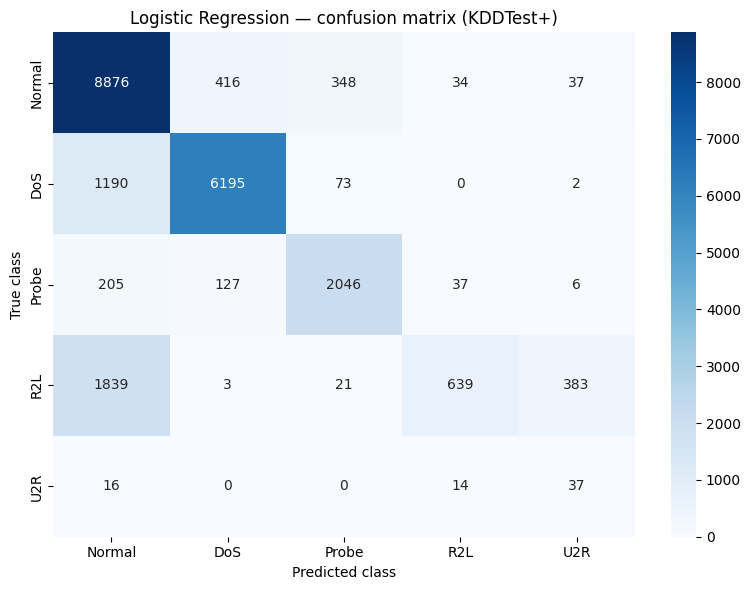

In [13]:
print("Classification report (test set):")
print(
    classification_report(
        y_test,
        y_pred,
        labels=category_order,
        digits=4,
        zero_division=0,
    )
)

cm = confusion_matrix(y_test, y_pred, labels=category_order)
cm_df = pd.DataFrame(cm, index=category_order, columns=category_order)
print("Confusion matrix (rows = true, columns = predicted):")
display(cm_df)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
)
plt.title("Logistic Regression — confusion matrix (KDDTest+)")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
plt.show()

## Baseline Interpretation

The figures below are taken from the test-set output already produced. They describe **what the model did**. They do not, by themselves, explain **why** those errors occurred.

**Overall scores (observed)**

- **Accuracy = 0.7893** — 78.93% of the 22,544 test rows were labeled correctly.
- **Macro F1 = 0.6024** — unweighted mean of the five per-class F1 scores.

**Stronger classes (observed in the classification report)**

- **Normal:** precision 0.7320, recall 0.9140, F1 0.8129 (support 9711)
- **DoS:** precision 0.9190, recall 0.8304, F1 0.8725 (support 7460)
- **Probe:** precision 0.8223, recall 0.8451, F1 0.8336 (support 2421)

These three have the highest F1 scores on KDDTest+.

**Weaker classes (observed)**

- **R2L recall = 0.2215** (precision 0.8826, F1 0.3541, support 2885). Most true R2L rows were not predicted as R2L.
- **U2R precision = 0.0796** with **U2R recall = 0.5522** (F1 0.1391, support 67). More than half of true U2R rows were found, but most rows predicted as U2R were not U2R.

**R2L → U2R (observed in the confusion matrix)**

Rows = true class; columns = predicted class (Normal, DoS, Probe, R2L, U2R).

True **R2L** counts: 1839 Normal, 3 DoS, 21 Probe, 639 R2L, **383 U2R**.

The U2R **prediction** column is 37 + 2 + 6 + 383 + 37 = **465**. Only **37** of those are true U2R; **383** are true R2L. That matches U2R precision 0.0796 (37 / 465). This is a count from the matrix, not a claim about why R2L and U2R were mixed up.

**Accuracy vs macro F1 (what the metrics do)**

Accuracy treats every **row** equally. Most test rows are Normal or DoS, and those classes scored well, so accuracy can be 0.7893 even though R2L recall is 0.2215 and U2R F1 is 0.1391.

Macro F1 treats every **class** equally. The low R2L and U2R F1 scores pull the average down to 0.6024. The gap between 0.7893 and 0.6024 is therefore the effect of **class imbalance on the choice of metric**: a row-weighted score can look much better than a class-weighted score when common classes dominate.

**Baseline role**

This Logistic Regression result is our **baseline**. Random Forest and XGBoost will be compared against these same test numbers, especially macro F1 and the R2L / U2R scores, not accuracy alone.